## EDS Outputs

In [5]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", None)
REGION = "ap-southeast-2"

session = boto3.session.Session(region_name=REGION)
s3 = session.client("s3")

print("Ready.")

Ready.


In [6]:
BUCKET = "dcceew-eds-data"
PREFIX = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/"

def scan_tf_files(bucket, prefix):
    paginator = s3.get_paginator("list_objects_v2")
    records = []

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if not key.lower().endswith(".tif"):
                continue

            # Extract tile name from path
            # e.g. .../tiles/p089r078/something.tf
            parts = key[len(prefix):].split("/")
            tile = parts[0] if parts else "UNKNOWN"

            records.append({
                "tile": tile,
                "key": key,
                "size_bytes": int(obj["Size"])
            })

    return pd.DataFrame(records)

df = scan_tf_files(BUCKET, PREFIX)

print("Total .tf files:", len(df))
df.head()

Total .tf files: 1098


,tile,key,size_bytes
0,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/2015/20150503/sl8olre_p089r078_20150503_ga1_28356.tif,40711311
1,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/2015/20150503/sl8olre_p089r078_20150503_ga1_e28356.tif,40711311
2,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/2015/20150503/sl8olre_p089r078_20150503_ga2_28356.tif,672013
3,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/2015/20150503/sl8olre_p089r078_20150503_ga2_e28356.tif,672013
4,p089r078,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p089r078/2015/20150519/sl8olre_p089r078_20150519_ga1_e28356.tif,36011207


In [7]:
summary = (
    df.groupby("tile")
      .agg(
          tf_count=("key", "count"),
          total_size_bytes=("size_bytes", "sum")
      )
      .sort_values("tf_count", ascending=False)
)

summary["total_size_mb"] = summary["total_size_bytes"] / (1024 * 1024)

summary.head(20)

,tf_count,total_size_bytes,total_size_mb
tile,,,
p091r076,334,7880251008,7515.192993
p089r078,266,4017287872,3831.184265
p091r077,254,19812504068,18894.676273
p089r083,220,7780591422,7420.150206
p102r072,24,2043050560,1948.404846


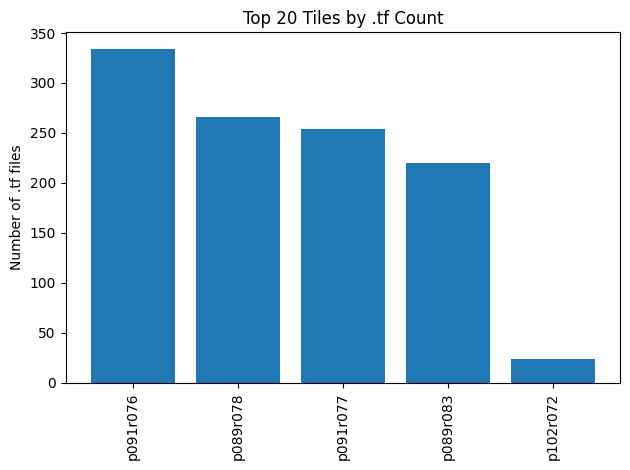

In [8]:
top_n = 20

summary_sorted = summary.sort_values("tf_count", ascending=False).head(top_n)

plt.figure()
plt.bar(summary_sorted.index, summary_sorted["tf_count"])
plt.xticks(rotation=90)
plt.ylabel("Number of .tf files")
plt.title(f"Top {top_n} Tiles by .tf Count")
plt.tight_layout()
plt.show()

In [9]:
def search_tiles(pattern):
    return summary.loc[summary.index.str.contains(pattern, case=False)]

search_tiles("p089")

,tf_count,total_size_bytes,total_size_mb
tile,,,
p089r078,266,4017287872,3831.184265
p089r083,220,7780591422,7420.150206


In [10]:
df[df["key"].str.contains("dll", case=False)].head(20)

,tile,key,size_bytes
817,p091r076,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r076/outputs/p091r076_d2025081620260131/lztmre_p091r076_d2025081620260107_vi-ndvi_dllmz_cog.tif,2150745
1071,p091r077,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r077/outputs/p091r077_d2025091720260131/lztmre_p091r077_d2025091720251206_vi-ndvi_dllmz_cog.tif,8754773


In [11]:
BUCKET = "dcceew-eds-data"
BASE_PREFIX = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/"

def scan_tile_outputs(bucket, base_prefix):
    paginator = s3.get_paginator("list_objects_v2")
    records = []

    for page in paginator.paginate(Bucket=bucket, Prefix=base_prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            # Only include outputs folders
            if "/outputs/" not in key:
                continue

            # Extract tile name
            # tiles/{tile}/outputs/...
            rel = key[len(base_prefix):]
            parts = rel.split("/")
            if len(parts) < 3:
                continue

            tile = parts[0]
            size = int(obj["Size"])

            records.append({
                "tile": tile,
                "key": key,
                "size_bytes": size,
                "extension": key.split(".")[-1].lower() if "." in key else "none"
            })

    return pd.DataFrame(records)


df_outputs = scan_tile_outputs(BUCKET, BASE_PREFIX)

print("Total output files:", len(df_outputs))
df_outputs.head()

Total output files: 38


,tile,key,size_bytes,extension
0,p091r076,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r076/outputs/p091r076_d2025081620260131/lztmre_p091r076_d2025081620260107_vi-ndvi_dljmz_cog.tif,13508425,tif
1,p091r076,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r076/outputs/p091r076_d2025081620260131/lztmre_p091r076_d2025081620260107_vi-ndvi_dllmz_cog.tif,2150745,tif
2,p091r076,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r076/outputs/p091r076_d2025081620260131/masks/lztmre_p091r076_p091r076_d2025081620260131_clear_ge80_mask_cog.tif,379147,tif
3,p091r076,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r076/outputs/p091r076_d2025081620260131/masks/lztmre_p091r076_p091r076_d2025081620260131_strong_ge60_mask_cog.tif,446399,tif
4,p091r076,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/p091r076/outputs/p091r076_d2025081620260131/vectors/clear_ge80/lztmre_p091r076_p091r076_d2023030420231022_clear_ge80.cpg,5,cpg


In [12]:
summary_outputs = (
    df_outputs
    .groupby("tile")
    .agg(
        file_count=("key", "count"),
        total_size_bytes=("size_bytes", "sum")
    )
    .sort_values("file_count", ascending=False)
)

summary_outputs["total_size_gb"] = summary_outputs["total_size_bytes"] / (1024**3)

summary_outputs.head(20)

,file_count,total_size_bytes,total_size_gb
tile,,,
p091r076,24,22698869,0.021140
p091r077,14,72571114,0.067587


In [13]:
# Get all tile folders
all_tiles = set()

paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=BUCKET, Prefix=BASE_PREFIX, Delimiter="/"):
    for cp in page.get("CommonPrefixes", []):
        tile = cp["Prefix"][len(BASE_PREFIX):].strip("/")
        all_tiles.add(tile)

tiles_with_outputs = set(summary_outputs.index)

missing_outputs = sorted(all_tiles - tiles_with_outputs)

print("Tiles with NO outputs folder:", len(missing_outputs))
missing_outputs[:20]

Tiles with NO outputs folder: 3


['p089r078', 'p089r083', 'p102r072']

In [14]:
type_summary = (
    df_outputs
    .groupby(["tile", "extension"])
    .size()
    .unstack(fill_value=0)
)

type_summary.head(10)

extension,cpg,dbf,prj,shp,shx,tif
tile,,,,,,
p091r076,4,4,4,4,4,4
p091r077,2,2,2,2,2,4


In [15]:
BUCKET = "dcceew-eds-data"
BASE = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/"

# Option A (preferred): NDVI stored under a known folder name
NDVI_SUBPATH = "/ndvi/"          # change if yours is different e.g. "/ndvi_tiles/" or "/inputs/ndvi/"

# Option B: NDVI identified by filename containing "ndvi"
NDVI_NAME_CONTAINS = "ndvi"      # set to None to disable

In [16]:
import pandas as pd

def count_ndvi_and_outputs(bucket: str, base_prefix: str, ndvi_subpath="/ndvi/", ndvi_name_contains="ndvi"):
    if base_prefix and not base_prefix.endswith("/"):
        base_prefix += "/"

    paginator = s3.get_paginator("list_objects_v2")

    # counts[tile] = dict(...)
    counts = {}

    for page in paginator.paginate(Bucket=bucket, Prefix=base_prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            size = int(obj["Size"])

            # skip folder markers
            if key.endswith("/") and size == 0:
                continue

            rel = key[len(base_prefix):]
            parts = rel.split("/")
            if len(parts) < 2:
                continue

            tile = parts[0]

            d = counts.setdefault(tile, {
                "tile": tile,
                "ndvi_files": 0,
                "ndvi_bytes": 0,
                "result_files": 0,
                "result_bytes": 0,
                "total_files": 0,
                "total_bytes": 0,
            })

            d["total_files"] += 1
            d["total_bytes"] += size

            # "results" == anything under outputs/
            if f"/{tile}/outputs/" in key:
                d["result_files"] += 1
                d["result_bytes"] += size

            # NDVI match:
            ndvi_hit = False

            # Folder-based
            if ndvi_subpath and f"/{tile}{ndvi_subpath}" in key:
                ndvi_hit = True

            # Name-based (fallback)
            if (not ndvi_hit) and ndvi_name_contains:
                if ndvi_name_contains.lower() in key.lower():
                    # but avoid counting results that merely mention NDVI in filenames if you don't want that:
                    # comment out next 2 lines if you *do* want outputs ndvi included
                    if f"/{tile}/outputs/" not in key:
                        ndvi_hit = True

            if ndvi_hit:
                d["ndvi_files"] += 1
                d["ndvi_bytes"] += size

    df = pd.DataFrame(counts.values()).sort_values("tile")
    for col in ["ndvi_bytes", "result_bytes", "total_bytes"]:
        df[col.replace("bytes", "gb")] = df[col] / (1024**3)
    return df

df_counts = count_ndvi_and_outputs(
    BUCKET,
    BASE,
    ndvi_subpath=NDVI_SUBPATH,
    ndvi_name_contains=NDVI_NAME_CONTAINS
)

df_counts.head(20)

,tile,ndvi_files,ndvi_bytes,result_files,result_bytes,total_files,total_bytes,ndvi_gb,result_gb,total_gb
0,p089r078,0,0,0,0,266,4017287872,0.000000,0.000000,3.741391
1,p089r083,0,0,0,0,220,7780591422,0.000000,0.000000,7.246240
2,p091r076,328,7636528962,24,22698869,354,7886465161,7.112072,0.021140,7.344843
3,p091r077,248,18854994932,14,72571114,264,19833654604,17.560082,0.067587,18.471530
4,p102r072,0,0,0,0,24,2043050560,0.000000,0.000000,1.902739


In [17]:
df_counts.sort_values("ndvi_files", ascending=False).head(20)[
    ["tile", "ndvi_files", "ndvi_gb", "result_files", "result_gb"]
]

,tile,ndvi_files,ndvi_gb,result_files,result_gb
2,p091r076,328,7.112072,24,0.021140
3,p091r077,248,17.560082,14,0.067587
0,p089r078,0,0.000000,0,0.000000
1,p089r083,0,0.000000,0,0.000000
4,p102r072,0,0.000000,0,0.000000


In [18]:
df_counts[df_counts["ndvi_files"] == 0][["tile", "result_files", "result_gb"]].head(50)

,tile,result_files,result_gb
0,p089r078,0,0.0
1,p089r083,0,0.0
4,p102r072,0,0.0


In [19]:
df_counts[df_counts["result_files"] == 0][["tile", "ndvi_files", "ndvi_gb"]].head(50)

,tile,ndvi_files,ndvi_gb
0,p089r078,0,0.0
1,p089r083,0,0.0
4,p102r072,0,0.0


In [20]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df_outputs[df_outputs["tile"] == "p089r078"]

,tile,key,size_bytes,extension
